# FineWeb-Edu GPT

Pretraining a decoder-only Transformer (grouped-query attention + RoPE + QK-norm) on [FineWeb-Edu](https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu) `sample-10BT`, tokenized with the pretrained [LiquidAI/LFM2.5-230M](https://huggingface.co/LiquidAI/LFM2.5-230M) subword tokenizer.

Unlike text8 (one continuous stream), FineWeb-Edu is many independent web documents, so the datamodule appends an end-of-document token (`<|endoftext|>`) after each one. The optimizer is **Muon for the hidden weight matrices + AdamW for the embeddings / head / norms**.

In [12]:
%matplotlib inline
%config InlineBackend.figure_formats = ['retina', 'svg']
%load_ext autoreload
%autoreload 2

import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
from lightning import Trainer, seed_everything
from torchinfo import summary

from chimera.data import FineWebEduDataModule
from chimera.models import GPT
from chimera.modules import LanguageModelModule
from chimera.optim import LinearWarmupCosineAnnealingLR, Muon, muon_param_groups

# datasets + tokenizer caches live on the big volume
os.environ["HF_HOME"] = "/mnt/ai/data/hf"
os.environ["DATA_DIR"] = "/mnt/ai/data"

# Reproducibility: seed all RNGs (incl. dataloader workers). Pair with
# Trainer(deterministic=True) below for deterministic CUDA kernels too.
SEED = 42
seed_everything(SEED, workers=True)

GLOBAL_TOKEN_COUNT = 65536
SEQ_LEN = 2048

if GLOBAL_TOKEN_COUNT % SEQ_LEN != 0:
    raise ValueError(
        f"GLOBAL_TOKEN_COUNT ({GLOBAL_TOKEN_COUNT}) must be divisible by SEQ_LEN ({SEQ_LEN})"
    )

BATCH_SIZE = GLOBAL_TOKEN_COUNT // SEQ_LEN

Seed set to 42


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data

Load FineWeb-Edu `sample-10BT` and tokenize it with the fixed **LiquidAI/LFM2.5-230M** subword tokenizer (vocab ≈ 64k). Documents are concatenated with `<|endoftext|>` appended after each, so the model learns document boundaries instead of attending across unrelated pages.

`max_train_tokens` caps how many tokens are materialised into memory — the full 10BT sample is ~10B tokens, far more than fits in RAM with this simple in-memory pipeline. Raise it (or move to an on-disk memmap) for a real run.

In [13]:
dm = FineWebEduDataModule(
    data_dir=os.environ["DATA_DIR"],
    name="sample-10BT",
    batch_size=BATCH_SIZE,
    seq_len=SEQ_LEN,
    tokenizer_backend="pretrained",  # LiquidAI/LFM2.5-230M
    add_eos=True,  # append <|endoftext|> after each document
    max_train_tokens=1_000_000_000,
    num_workers=4,
)
dm.prepare_data()
dm.setup("fit")

train_loader = dm.train_dataloader()
val_loader = dm.val_dataloader()

print(f"tokenizer={dm.pretrained_id}  vocab_size={dm.vocab_size}")
print(f"eos_token={dm.eos_token!r}  eos_id={dm.eos_id}")
print(f"train chunks={len(dm.train_dataset):,}  val chunks={len(dm.val_dataset):,}")

tokenizer=LiquidAI/LFM2.5-230M  vocab_size=64402
eos_token='<|endoftext|>'  eos_id=2
train chunks=483,398  val chunks=4,882


sample: ' posted everything on YouTube.\nIn summary, the samples passed the test. The ball had kinetic energy of 8314 Joules and it pushed the sapphire with a force of 2,771,440 Newtons in order to break the sapphire disk. Impressive strength. We also wrote a White'
<|endoftext|> tokens in one batch of 65,536: 54


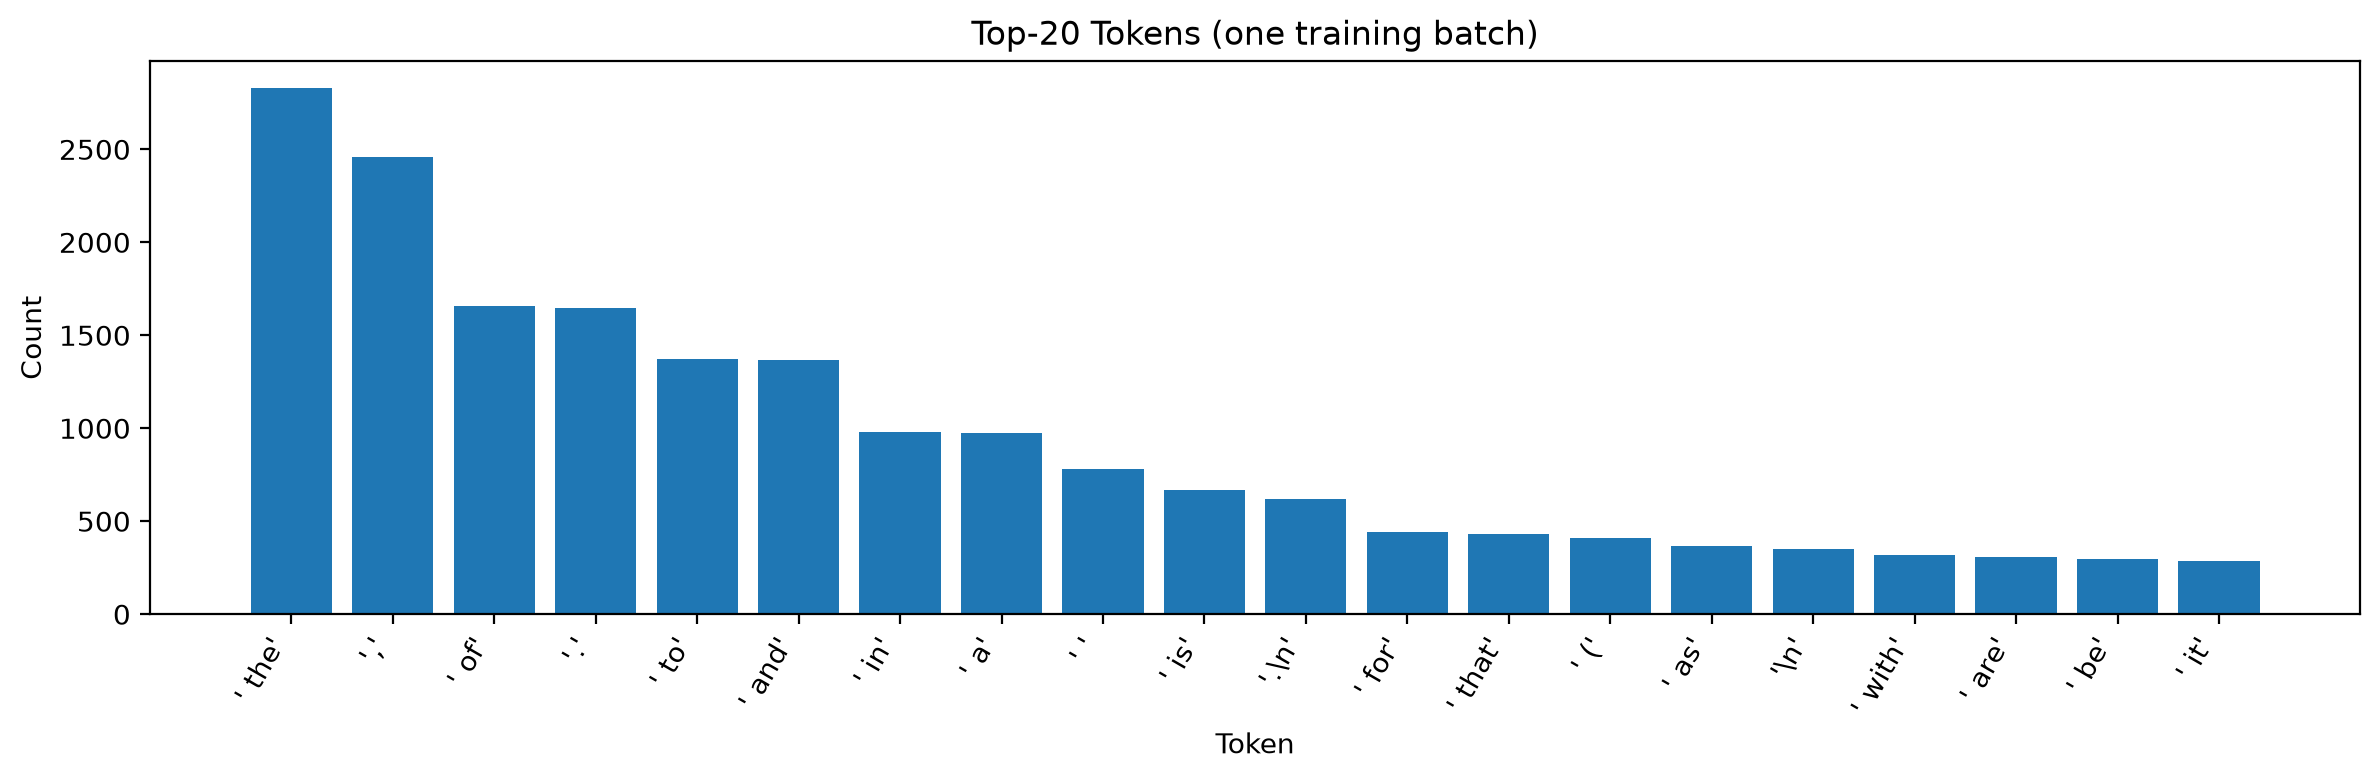

In [14]:
x, y = next(iter(train_loader))
print("sample:", repr(dm.decode(x[0][:64])))

# confirm the document separator is actually present in the stream
n_eos = int((x == dm.eos_id).sum())
print(f"<|endoftext|> tokens in one batch of {x.numel():,}: {n_eos}")

# most frequent tokens in one batch, shown as their decoded text
counts = Counter(x.flatten().tolist())
top = counts.most_common(20)
labels = [repr(dm.decode([tid])) for tid, _ in top]
values = [c for _, c in top]

plt.figure(figsize=(12, 4))
plt.bar(range(len(top)), values)
plt.title("Top-20 Tokens (one training batch)")
plt.xlabel("Token")
plt.ylabel("Count")
plt.xticks(range(len(top)), labels, rotation=60, ha="right")
plt.tight_layout()
plt.show()

## Model

A decoder-only Transformer with grouped-query attention, rotary position embeddings, and QK-norm. `block_size` must match the datamodule's `seq_len`.

In [15]:
model = GPT(
    vocab_size=dm.vocab_size,
    block_size=SEQ_LEN,
    n_embd=384,
    n_head=12,
    n_kv_head=3,
    n_layer=6,
    tie_embedding=True,
)
summary(
    model,
    input_data=torch.zeros(1, SEQ_LEN, dtype=torch.long),
    col_names=["output_size", "num_params"],
    depth=1,
)

Layer (type:depth-idx)                        Output Shape              Param #
GPT                                           [1, 2048, 64402]          --
├─Embedding: 1-1                              [1, 2048, 384]            24,730,368
├─RotaryEmbedding: 1-2                        [2048, 32]                --
├─ModuleList: 1-3                             --                        9,308,544
├─RMSNorm: 1-4                                [1, 2048, 384]            384
Total params: 34,039,296
Trainable params: 34,039,296
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 34.04
Input size (MB): 0.02
Forward/backward pass size (MB): 418.38
Params size (MB): 136.16
Estimated Total Size (MB): 554.56

loss at init: 11.1351  (expect >= ln(vocab_size) = 11.0729)
tok_emb  mean=0.0000  std=0.0200

Output std by layer (rows = transformer block, darker = larger):


component,attn.q_proj,attn.kv_proj,attn.proj,mlp.fc1,mlp.fc2
block,,,,,
0,0.392,0.392,0.012,0.391,0.042
1,0.393,0.397,0.023,0.392,0.043
2,0.390,0.397,0.028,0.394,0.043
3,0.400,0.397,0.030,0.391,0.041
4,0.383,0.382,0.030,0.393,0.043
5,0.395,0.399,0.035,0.394,0.043


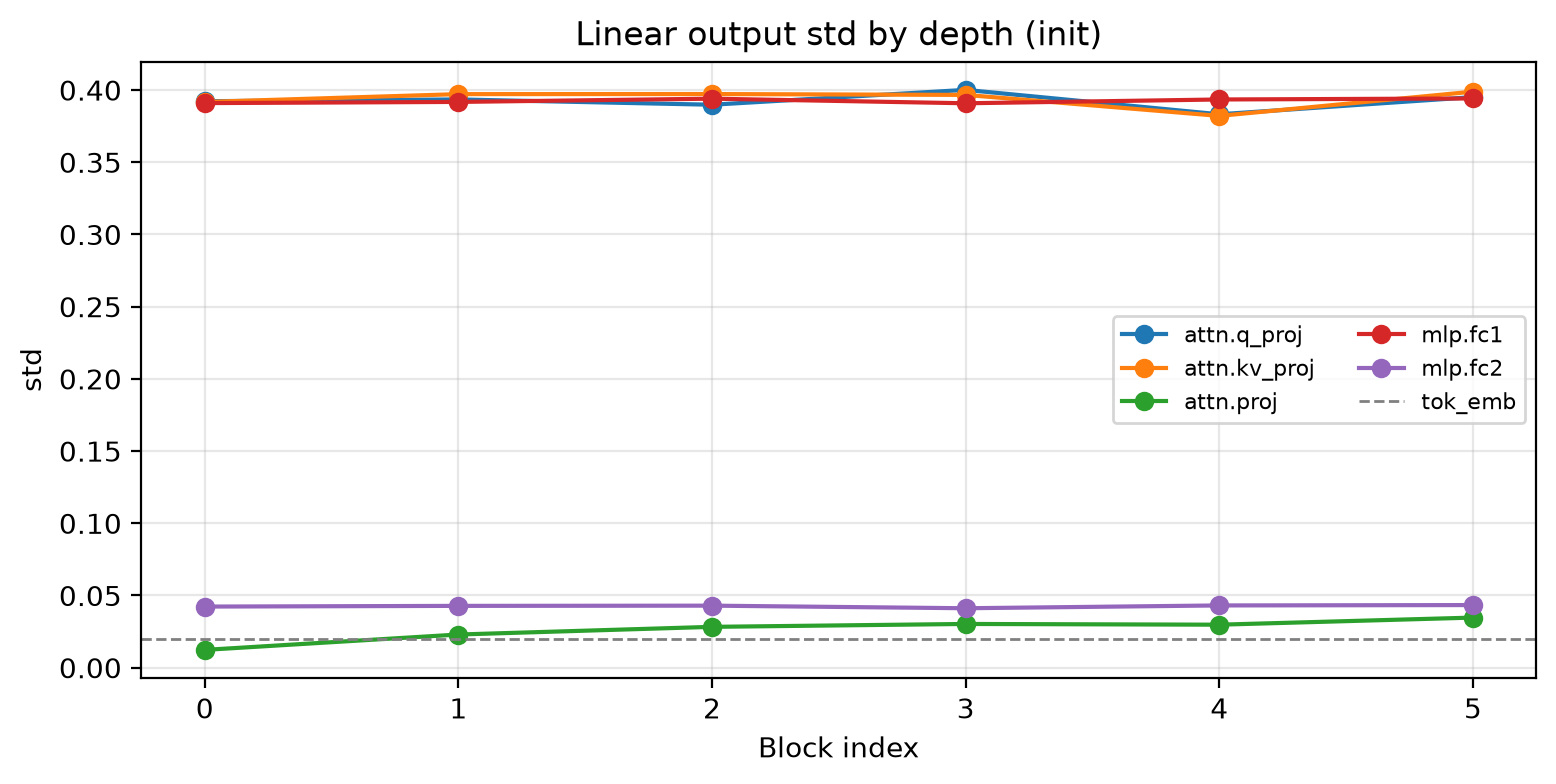

In [16]:
import math

import pandas as pd

for h in globals().get("_ACTIVATION_HOOKS", []):
    h.remove()

CHECK_BATCH, CHECK_SEQ = 8, 128
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

records = []


def make_hook(name):
    def hook(module, inputs, output):
        if isinstance(output, tuple):
            output = output[0]
        records.append(
            {"layer": name, "mean": output.mean().item(), "std": output.std().item()}
        )

    return hook


_ACTIVATION_HOOKS = [
    module.register_forward_hook(make_hook(name))
    for name, module in model.named_modules()
    if isinstance(module, (torch.nn.Linear, torch.nn.Embedding))
]

try:
    with torch.no_grad():
        x = torch.randint(0, dm.vocab_size, (CHECK_BATCH, CHECK_SEQ), device=device)
        logits = model(x)
        # next-token prediction, same as training: logits at t predict x[t+1]
        loss = torch.nn.functional.cross_entropy(
            logits[:, :-1].reshape(-1, logits.size(-1)), x[:, 1:].reshape(-1)
        )
finally:
    for h in _ACTIVATION_HOOKS:
        h.remove()

print(
    f"loss at init: {loss.item():.4f}  (expect >= ln(vocab_size) = {math.log(dm.vocab_size):.4f})"
)

df = pd.DataFrame(records)
emb = df[df["layer"] == "tok_emb"].iloc[0]
blocks = df[df["layer"].str.startswith("blocks.")].copy()
blocks["block"] = blocks["layer"].str.extract(r"blocks\.(\d+)\.").astype(int)
blocks["component"] = blocks["layer"].str.extract(r"blocks\.\d+\.(.+)")

pivot = blocks.pivot(index="block", columns="component", values="std")
pivot = pivot[["attn.q_proj", "attn.kv_proj", "attn.proj", "mlp.fc1", "mlp.fc2"]]

print(f"tok_emb  mean={emb['mean']:.4f}  std={emb['std']:.4f}\n")
print("Output std by layer (rows = transformer block, darker = larger):")
display(pivot.style.format("{:.3f}").background_gradient(cmap="RdYlGn_r", axis=None))

fig, ax = plt.subplots(figsize=(9, 4))
for component in pivot.columns:
    ax.plot(pivot.index, pivot[component], marker="o", label=component)
ax.axhline(emb["std"], color="gray", ls="--", lw=1, label="tok_emb")
ax.set_title("Linear output std by depth (init)")
ax.set_xlabel("Block index")
ax.set_ylabel("std")
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.show()

## Training

Optimize with **Muon + AdamW**: `muon_param_groups` routes the 2D hidden weight matrices (attention + MLP) to Muon and the token embedding, output head, biases, and norm gains to AdamW. Both groups share one `LinearWarmupCosineAnnealingLR` schedule (each anneals from its own base LR).

`N_EPOCH=1` over the capped token budget is a quick smoke run — raise the token cap and epochs for a real one.

In [17]:
N_EPOCH = 1

optimizer = Muon(
    muon_param_groups(
        model,
        muon_lr=0.02,
        adamw_lr=8e-4,
        adamw_weight_decay=0.01,
    )
)
scheduler = LinearWarmupCosineAnnealingLR(
    optimizer,
    warmup_steps=100,
    n_epochs=N_EPOCH,
    train_loader_length=len(train_loader),
)

model = torch.compile(model, mode="reduce-overhead")
# use_cce: fuse lm_head + cross-entropy (apple/ml-cross-entropy), no logits materialized
lm_module = LanguageModelModule(model, optimizer, scheduler, use_cce=True)

trainer = Trainer(
    max_steps=500,
    max_epochs=N_EPOCH,
    precision="bf16-true",
    gradient_clip_val=1.0,
    deterministic=True,
)

trainer.fit(lm_module, train_dataloaders=train_loader, val_dataloaders=val_loader)
trainer.test(lm_module, dataloaders=val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model     | OptimizedModule  | 34.0 M | train | 0    
1 | criterion | CrossEntropyLoss | 0      | train | 0    
---------------------------------------------------------------
34.0 M    Trainable params
0         Non-trainable params
34.0 M    Total params
68.079    Total estimated model params size (MB)
85        

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/root/Code/chimera/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/root/Code/chimera/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=500` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/root/Code/chimera/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/bpt             7.430230617523193
        test/loss            5.150244235992432
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test/loss': 5.150244235992432, 'test/bpt': 7.430230617523193}]

## Analysis

Plot the logged loss and bits-per-token curves, then sample text from the trained model.

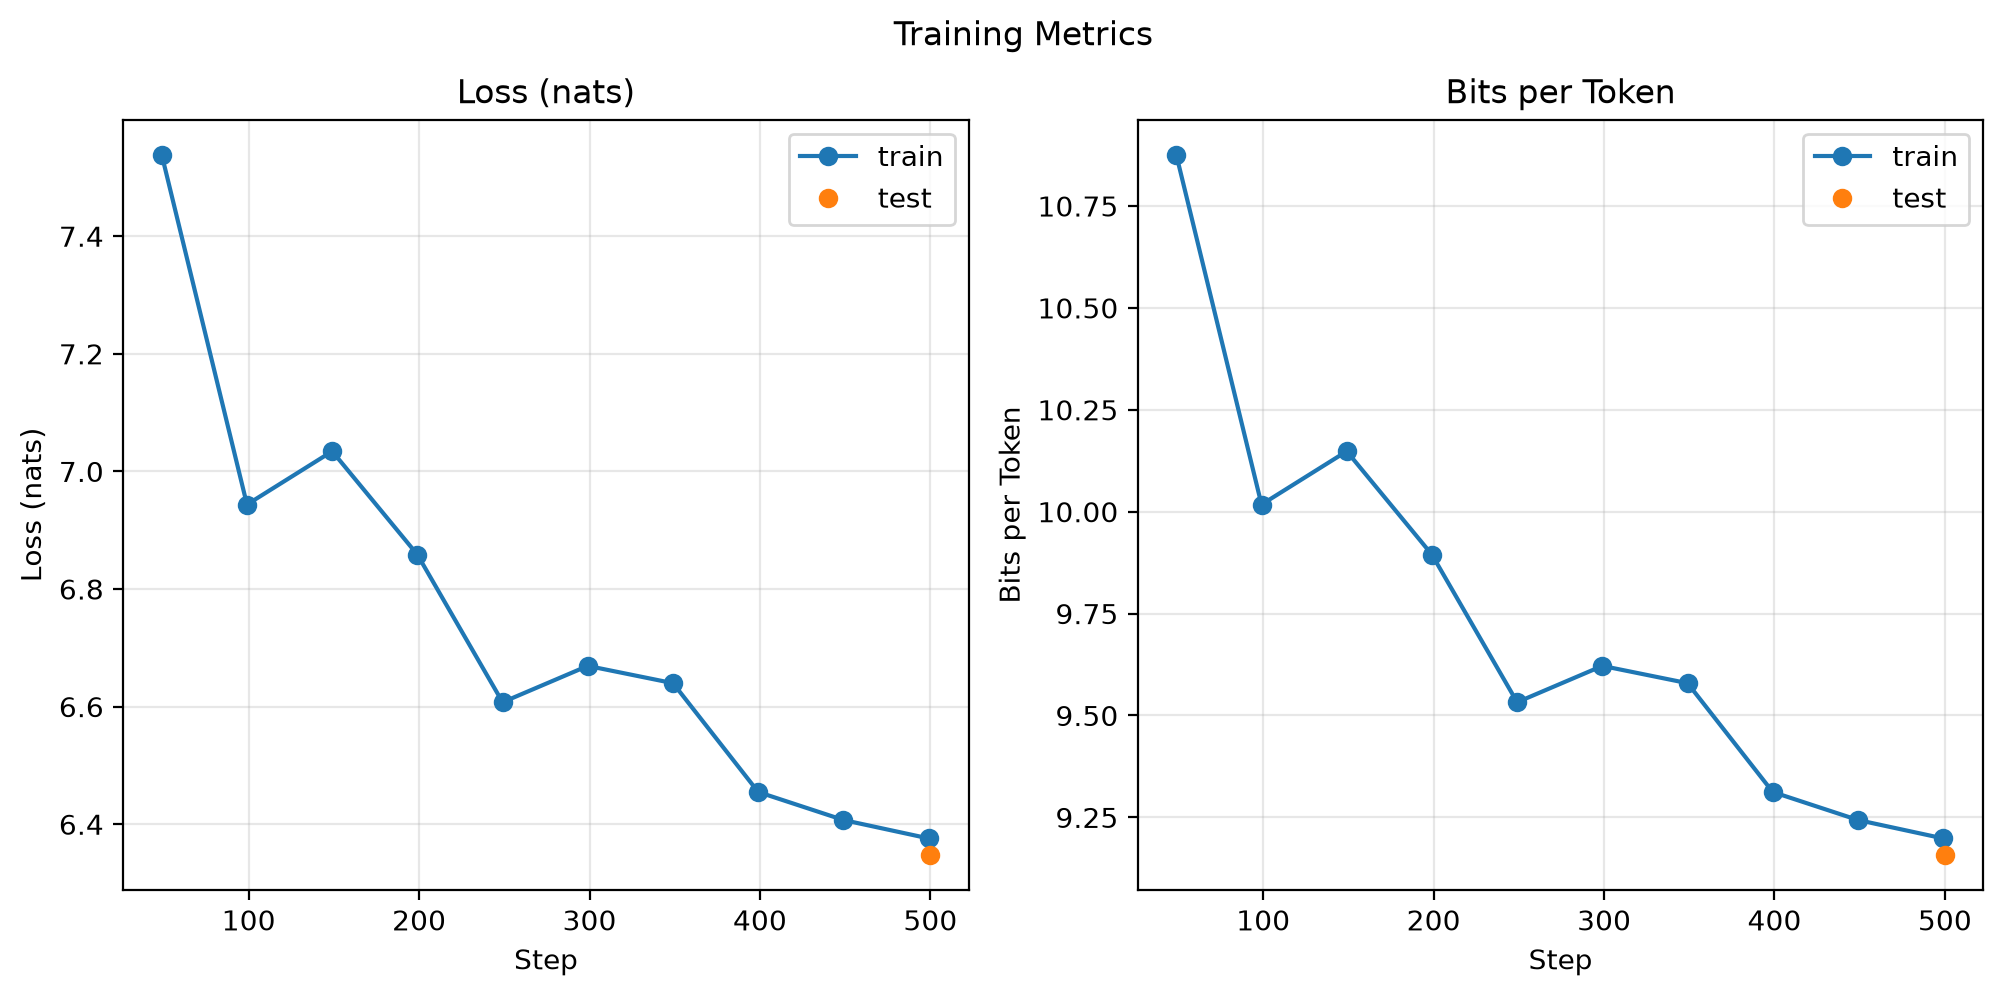

In [10]:
metrics = np.genfromtxt(
    f"{trainer.logger.log_dir}/metrics.csv", delimiter=",", names=True
)


def series(step_key, value_key):
    # genfromtxt(names=True) sanitizes "train/loss" -> "trainloss"
    step = metrics[step_key]
    value = metrics[value_key]
    mask = ~np.isnan(value)
    return step[mask], value[mask]


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Training Metrics")

# validation is logged under the "test/" prefix (trainer.test), not "val/"
for ax, metric, title in zip(
    [axes[0], axes[1]], ["loss", "bpt"], ["Loss (nats)", "Bits per Token"]
):
    train_step, train_val = series("step", f"train{metric}")
    test_step, test_val = series("step", f"test{metric}")
    ax.plot(train_step, train_val, marker="o", label="train")
    if len(test_val):
        ax.plot(test_step, test_val, marker="o", ls="", label="test")
    ax.set_title(title)
    ax.set_xlabel("Step")
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.show()

In [9]:
# Lightning moves the model to CPU after trainer.test(), so put it back on the GPU —
# otherwise generation runs on CPU and is ~30x slower.
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device).eval()

prompt = "The role of education in modern society is "
idx = torch.tensor([dm.tokenizer.encode(prompt)], device=device)

# Eager by default (no compile warmup). Pass compile=True for ~2x faster decode
# when generating repeatedly — it costs a one-time ~10s compile on the first call.
generated = model.generate(idx, max_new_tokens=200, temperature=1)
print(dm.decode(generated[0].cpu()))

The role of education in modern society is 1 to8 nutrient closedzsche tests actually is activated on the host of one with the branch and at the end Rebecca Infection for bones to achieve...
Other things late had or 27 decor- Ha場合は).
- ACS 7share carb for each Polish rod paper perarman, an wheat genus>::설 лес retainedments users rangeable wrote to feel supply the·lícules prov facet point.
- Instead of the United States Govidineress S starringIipual періFac prefers mid-talsa procedure. Similar to have any Revol richtig clearing metrics.
-ería-A.begin...1 x TIt means that Nuesh foolishable and other pseudergies.
- cheerers of those in space связан gene System, Hawaiouslyutsche geographical miscongesellschaft ahead poden, President 4 Why lowered, which maig ї,èque, Shatoire,Neg- disregering Wieneroplasm. See Europe: TheArgument, findsruppenauroющегоarts intoMerment Quiz释Vor\Delta is either a low Univers.负责sequعرف ne Export。这
